In [21]:
import ultranest
import george
import numpy as np
import matplotlib.pyplot as plt
from ultranest.plot import cornerplot
from ultranest import ReactiveNestedSampler
from ultranest.plot import PredictionBand
from george.modeling import Model
from george import kernels, GP
from scipy.optimize import minimize
from time import time

# %matplotlib widget
# plt.close('all')

## Load dataset

File creati e caricati correttamente!
Mesi caricati (Sezione Aria): 2100
Mesi caricati (Sezione Acqua): 2100


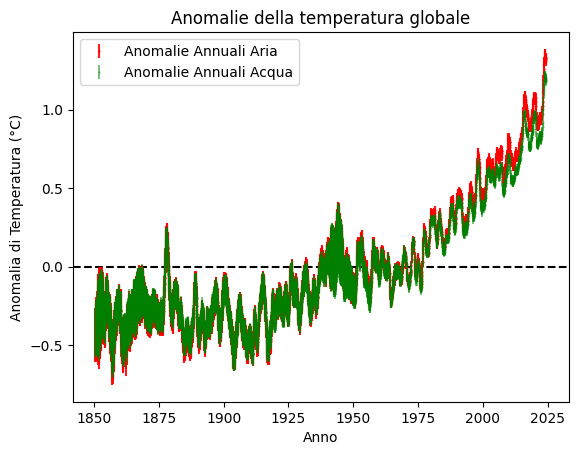

In [22]:
filename = 'Land_and_Ocean_complete.txt'
separator = "% Global Average Temperature Anomaly with Sea Ice Temperature Inferred from Water Temperatures"

with open(filename, 'r') as f:
    content = f.read()

parts = content.split(separator)

with open('data_air.txt', 'w') as f:
    f.write(parts[0])

with open('data_water.txt', 'w') as f:
    f.write(separator + parts[1])

data_air_raw = np.genfromtxt('data_air.txt', comments='%', filling_values=np.nan)
data_water_raw = np.genfromtxt('data_water.txt', comments='%', filling_values=np.nan)

print("File creati e caricati correttamente!")
def to_dict(raw):
    # Tempo in anni decimali: Anno + (Mese - 0.5)/12
    years = raw[:, 0]
    months = raw[:, 1]
    time_years = years + (months - 0.5) / 12
    t_ref = np.min(years)
    time_centered = time_years - t_ref
    return {
        "time_years": time_years,
        "time_centered": time_centered,
        "Year": raw[:,0].astype(int), 
        "Month": raw[:,1].astype(int), 
        "Monthly_Anomaly": raw[:,2], 
        "Monthly_Anomaly_Unc": raw[:,3], 
        "Annual_Anomaly": raw[:,4], 
        "Annual_Anomaly_Unc": raw[:,5], 
        "Five_Year_Anomaly": raw[:,6], 
        "Five_Year_Anomaly_Unc": raw[:,7], 
        "Ten_Year_Anomaly": raw[:,8], 
        "Ten_Year_Anomaly_Unc": raw[:,9], 
        "Twenty_Year_Anomaly": raw[:,10], 
        "Twenty_Year_Anomaly_Unc": raw[:,11], 
    }

data_air = to_dict(data_air_raw)
data_water = to_dict(data_water_raw)

print(f"Mesi caricati (Sezione Aria): {len(data_air['Year'])}")
print(f"Mesi caricati (Sezione Acqua): {len(data_water['Year'])}")

plt.Figure(figsize=(10, 6))
plt.errorbar(data_air['time_years'], data_air['Annual_Anomaly'], yerr=data_air['Annual_Anomaly_Unc'], fmt='.r', markersize=1, zorder=1, alpha=0.9, label='Anomalie Annuali Aria')
plt.errorbar(data_water['time_years'], data_water['Annual_Anomaly'], yerr=data_water['Annual_Anomaly_Unc'], fmt='.g', markersize=1, zorder=2, alpha=0.5, label='Anomalie Annuali Acqua')
plt.xlabel('Anno')
plt.ylabel('Anomalia di Temperatura (°C)')
plt.title('Anomalie della temperatura globale')
plt.axhline(0, color='black', linestyle='--', zorder=0)
plt.legend()
plt.show()

## Models definition

In [23]:
def constant_model(t, intercept):
    return intercept + t*0

def linear_model(t, a, b):
    return b + a*t

def quadratic_model(t, a, b, c):
    return c + b*t + a*t**2

def exponential_model(t, a, b, c):
    return a * np.exp(b*t) + c

In [24]:
param_constant = ['intercept']
param_linear = ['a', 'b']
param_quadratic = ['a', 'b', 'c']
param_exponential = ['a', 'b', 'c']

def prior_constant(cube):

    params = cube.copy()

    params[0] = cube[0] * 10 - 5

    return params

def prior_linear(cube):

    params = cube.copy()

    params[0] = cube[0] * 10
    params[1] = cube[1] * 10 - 5

    return params

def prior_quadratic(cube):

    params = cube.copy()

    params[0] = cube[0] * 2 - 1
    params[1] = cube[1] * 10 - 5
    params[2] = cube[2] * 10 - 5

    return params

def prior_exponential(cube):

    params = cube.copy()

    params[0] = cube[0] * 2.0
    params[1] = cube[1] * 0.05
    params[2] = cube[2] * 10 - 5
    
    return params

def log_likelihood_constant(params, data):
    
    intercept = params

    model = constant_model(data['time_centered'], intercept)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_linear(params, data):
    
    a, b = params

    model = linear_model(data['time_centered'], a, b)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2)

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_quadratic(params, data):
    
    a, b, c = params

    model = quadratic_model(data['time_centered'], a, b, c)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_exponential(params, data):
    
    a, b, c = params

    model = exponential_model(data['time_centered'], a, b, c)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

## Ultranest 

In [26]:
datasets = {
    'air': data_air,
    'water': data_water
}

models_config = {
    'const': (param_constant, log_likelihood_constant, prior_constant),
    'linear': (param_linear, log_likelihood_linear, prior_linear),
    'quadratic': (param_quadratic, log_likelihood_quadratic, prior_quadratic),
    'exponential': (param_exponential, log_likelihood_exponential, prior_exponential),
}

results = {}
samplers = {}

for model_label, (params, loglike_fn, prior_fn) in models_config.items():
    for data_label, data in datasets.items():
        
        run_id = f"{data_label}_{model_label}" 
        print(f"STARTING RUN: {run_id.upper()}")
        
        sampler = ReactiveNestedSampler(
            params, 
            lambda p, d=data: loglike_fn(p, d), 
            prior_fn
        )
        
        res = sampler.run(min_num_live_points=400, dKL=np.inf, min_ess=100)

        samplers[run_id] = sampler
        results[run_id] = res
        
        print(f"\nDONE: {run_id}")
        sampler.print_results()

STARTING RUN: AIR_CONST
[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-8e+04  -81416.72 [-81416.7250..-81416.7250]*| it/evals=4680/5237 eff=96.7542% N=400 0   0  
[ultranest] Likelihood function evaluations: 5249
[ultranest]   logZ = -8.143e+04 +- 0.1135
[ultranest] Effective samples strategy satisfied (ESS = 1240.5, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.08 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.12, need <0.5)
[ultranest]   logZ error budget: single: 0.14 bs:0.11 tail:0.03 total:0.12 required:<0.50
[ultranest] done iterating.

DONE: air_const

logZ = -81425.049 +- 0.212
  single instance: logZ = -81425.049 +- 0.140
  bootstrapped   : logZ = -81425.023 +- 0.210
  tail           : logZ = +- 0.033
insert order U test : converged: True correlation: inf iterations

    intercept           : 0.34452│ ▁  ▁ ▁▁▁▁▁▁▁▂▃▄▃▅▇▇▇▇▇▆▅▄▄▃▂▂▁▁▁▁▁▁▁▁ │0.35310    0.34918 +- 0.00099

STARTING RUN: WATER_CONST
[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-7e+04  -74211.44 [-74211.4407..-74211.4407]*| it/evals=4480/5033 eff=96.6976% N=400 0   0  
[ultranest] Likelihood function evaluations: 5068
[ultranest]   logZ = -7.422e+04 +- 0.12
[ultranest] Effective samples strategy satisfied (ESS = 1249.4, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.13, need <0.5)
[ultranest]   logZ error budget: single: 0.14 bs:0.12 tail:0.04 total:0.13 required:<0.50
[ultranest] done iterating.

DONE: water_const

logZ = -74219.549 +- 0.231
  single instance: logZ = -74219.549 +- 0.138
  bootstrapped   : logZ = -74219.572 +- 0.228
  tail           : logZ = +- 0.041
insert order U test : converged: True correlation: inf iterations

    intercept           : 0.31551│ ▁▁▁▁▁▁▁▁▂▂▃▃▄▆▆▇▇▇▇▅▆▅▄▃▂▂▁▁▁▁▁▁▁▁▁ ▁ │0.32339    0.31920 +- 0.00096

STARTING RUN: AIR_LINEAR
[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-2e+04  -20185.62 [-20185.6275..-20185.6275]*| it/evals=9800/13355 eff=75.6465% N=400    0 0 00 
[ultranest] Likelihood function evaluations: 13396
[ultranest]   logZ = -2.021e+04 +- 0.1766
[ultranest] Effective samples strategy satisfied (ESS = 1607.8, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.09 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.22 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.

DONE: air_linear

logZ = -20205.592 +- 0.339
  single instance: logZ = -20205.592 +- 0.218
  bootstrapped   : logZ = -20205.645 +- 0.339
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.009907│ ▁ ▁▁▁▁▁▁▁▂▂▃▃▄▅▇▇▇▇▇▇▆▅▄▄▄▃▂▁▁▁▁▁▁ ▁▁ │0.010138    0.010024 +- 0.000028
    b                   : -0.9826│ ▁▁▁▁▁▁▁▁▁▂▃▃▅▆▆▆▇▇▇▆▇▅▄▃▃▂▁▁▁▁▁▁▁▁

[ultranest] Explored until L=-2e+04  -18230.81 [-18230.8219..-18230.8218]*| it/evals=9840/13324 eff=76.1374% N=400    0   0  
[ultranest] Likelihood function evaluations: 13345
[ultranest]   logZ = -1.825e+04 +- 0.1641
[ultranest] Effective samples strategy satisfied (ESS = 1594.2, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.16, need <0.5)
[ultranest]   logZ error budget: single: 0.22 bs:0.16 tail:0.01 total:0.16 required:<0.50
[ultranest] done iterating.

DONE: water_linear

logZ = -18250.838 +- 0.260
  single instance: logZ = -18250.838 +- 0.218
  bootstrapped   : logZ = -18250.846 +- 0.260
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.009030│ ▁▁▁▁▁▁▁▁▁▂▂▃▄▅▅▆▇▇▇▇▇▆▅▄▃▃▂▁▁▁▁▁▁▁▁ ▁ │0.009260    0.009144 +- 0.000027
    b                   : -0.9099│ ▁▁▁▁▁▁▁▁▁▂▂▄▃▅▅▇▆▇▇▇▇▆▅▃▃▂▂▁▁▁▁▁

[ultranest] Explored until L=-2e+03  138.32 [-2138.3791..-2138.3790]*| it/evals=15480/30148 eff=52.0371% N=400    0    0  00 
[ultranest] Likelihood function evaluations: 30169
[ultranest]   logZ = -2172 +- 0.196
[ultranest] Effective samples strategy satisfied (ESS = 1899.9, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.20, need <0.5)
[ultranest]   logZ error budget: single: 0.29 bs:0.20 tail:0.01 total:0.20 required:<0.50
[ultranest] done iterating.

DONE: air_quadratic

logZ = -2172.478 +- 0.466
  single instance: logZ = -2172.478 +- 0.286
  bootstrapped   : logZ = -2172.430 +- 0.466
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.00009937│ ▁ ▁▁▁▁▁▁▁▁▂▃▃▄▆▇▇▇▇▇▆▆▄▃▃▂▁▁▁▁▁▁▁▁ ▁▁ │0.00010507    0.00010215 +- 0.00000061
    b                   : -0.01207│ ▁▁  ▁▁▁▁▁▁▁▁▂▂▃▅▅▆▇▇▇▇▇▅▄▃▃▂▁▁▁

[ultranest] Explored until L=-2e+03  948.94 [-1948.9959..-1948.9958]*| it/evals=15680/30004 eff=52.9658% N=400    0    0  00  
[ultranest] Likelihood function evaluations: 30004
[ultranest]   logZ = -1984 +- 0.2209
[ultranest] Effective samples strategy satisfied (ESS = 1901.6, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.18 to 0.56, need <0.5)
[ultranest]   logZ error budget: single: 0.29 bs:0.22 tail:0.01 total:0.22 required:<0.50
[ultranest] done iterating.

DONE: water_quadratic

logZ = -1983.572 +- 0.342
  single instance: logZ = -1983.572 +- 0.288
  bootstrapped   : logZ = -1983.642 +- 0.342
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.00008718│ ▁ ▁▁▁▁▁▁▁▁▂▂▃▃▄▄▆▇▇▇▇▇▆▅▄▃▃▂▂▁▁▁▁▁▁▁▁ │0.00009197    0.00008969 +- 0.00000057
    b                   : -0.0102

[ultranest] Explored until L=-2e+03  681.17 [-1681.2233..-1681.2233]*| it/evals=10600/174272 eff=6.0964% N=400       0  
[ultranest] Likelihood function evaluations: 174309
[ultranest]   logZ = -1703 +- 0.1439
[ultranest] Effective samples strategy satisfied (ESS = 1864.7, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.14, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:0.14 tail:0.01 total:0.14 required:<0.50
[ultranest] done iterating.

DONE: air_exponential

logZ = -1703.144 +- 0.289
  single instance: logZ = -1703.144 +- 0.227
  bootstrapped   : logZ = -1703.128 +- 0.289
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.02978│ ▁▁▁▁▁▁▂▂▂▂▄▅▇▇▇▇▇▇▆▆▅▃▃▂▁▁▁▁▁▁▁▁▁   ▁ │0.03801    0.03335 +- 0.00094
    b                   : 0.02138│ ▁  ▁▁▁▁▁▁▁▁▁▂▄▄▅▆▇▇▇▇▇▆▇▅▄▂▂▂▁▁▁▁▁▁▁▁ │0.0227

[ultranest] Explored until L=-2e+03  687.33 [-1687.3867..-1687.3866]*| it/evals=10760/98318 eff=10.9888% N=400   0  0 0  0 
[ultranest] Likelihood function evaluations: 98321
[ultranest]   logZ = -1710 +- 0.137
[ultranest] Effective samples strategy satisfied (ESS = 1877.7, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.14, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:0.14 tail:0.01 total:0.14 required:<0.50
[ultranest] done iterating.

DONE: water_exponential

logZ = -1709.668 +- 0.321
  single instance: logZ = -1709.668 +- 0.228
  bootstrapped   : logZ = -1709.639 +- 0.321
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.0305│ ▁ ▁ ▁▁▁▁▁▁▁▂▂▃▅▅▆▆▇▇▇▇▆▅▅▃▃▂▂▁▁▁▁▁▁▁▁ │0.0394    0.0352 +- 0.0011
    b                   : 0.02056│ ▁▁▁▁▁▁▁▁▂▂▃▄▆▆▇▇▇▆▇▆▄▅▃▂▂▂▁▁▁▁▁▁▁ ▁ ▁ │0.02196

## Constant fit

In [ ]:
fig = plt.figure(figsize=(16, 12))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.2, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_const'], fig=corner_subfigs[0], title_fmt='.4f')
corner_subfigs[0].suptitle('Corner Air (Costante)', fontsize=14)

cornerplot(results['water_const'], fig=corner_subfigs[1], title_fmt='.4f')
corner_subfigs[1].suptitle('Corner Water (Costante)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def add_constant_band(ax, res_key, data, color, label_name):
    samples = results[res_key]['samples']
    band = PredictionBand(t_grid)

    for val in samples:
        band.add(np.full_like(t_grid, val))
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)
    
    band.line(ax=ax, color=color, lw=2, label=f'Fit {label_name}', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)        # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2) # 2-sigma (95% approx)

add_constant_band(ax, 'air_const', data_air, 'blue', 'Aria')
add_constant_band(ax, 'water_const', data_water, 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Costante (Prediction Band)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

## Linear fit

In [ ]:
fig = plt.figure(figsize=(16, 14))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.5, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_linear'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Linear)', fontsize=14)

cornerplot(results['water_linear'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Linear)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_linear_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']

    band = PredictionBand(t_grid)

    for a, b in samples:
        band.add(a * t_grid + b)
        
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)
    
    band.line(ax=ax, color=color, lw=2, label=f'Trend {label_prefix}', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)        # 1-sigma
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2) # 2-sigma

plot_linear_with_bands(ax, data_air, 'air_linear', 'blue', 'Aria')
plot_linear_with_bands(ax, data_water, 'water_linear', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Lineare (°C/anno)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

KeyError: 'air_linear'

<Figure size 1600x1400 with 0 Axes>

## Quadratic fit

In [ ]:
fig = plt.figure(figsize=(20, 19))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.8, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_quadratic'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Quadratico)', fontsize=14)

cornerplot(results['water_quadratic'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Quadratico)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_quadratic_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']
    
    band = PredictionBand(t_grid)
    
    for a, b, c in samples:
        band.add(a * t_grid**2 + b * t_grid + c)
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)

    band.line(ax=ax, color=color, lw=2.5, label=f'Fit {label_prefix} (Quadratico)', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)         # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2)  # 2-sigma (95%)

plot_quadratic_with_bands(ax, data_air, 'air_quadratic', 'blue', 'Aria')
plot_quadratic_with_bands(ax, data_water, 'water_quadratic', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Quadratico ($y = at^2 + bt + c$)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

## Exponential fit

In [ ]:
fig = plt.figure(figsize=(20, 19))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.8, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_exponential'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Esponenziale)', fontsize=14)

cornerplot(results['water_exponential'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Esponenziale)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_exponential_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']

    band = PredictionBand(t_grid)

    for a, b, c in samples:
        band.add(a * np.exp(b * t_grid) + c)
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)
    
    band.line(ax=ax, color=color, lw=2.5, label=f'Trend {label_prefix} (Esponenziale)', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)         # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2)  # 2-sigma (95%)

plot_exponential_with_bands(ax, data_air, 'air_exponential', 'blue', 'Aria')
plot_exponential_with_bands(ax, data_water, 'water_exponential', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Esponenziale ($y = a \cdot e^{bt} + c$)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

## Models comparison

In [ ]:
dataset_labels = ['air', 'water']
model_labels = ['const', 'linear', 'quadratic', 'exponential']

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = COSTANTE): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_const"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = LINEARE): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_linear"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = QUADRATICO): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_quadratic"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = ESPONENZIALE): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_exponential"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

## Gaussian Process no trend

In [ ]:
# Pulizia dei dati dai valori nan
t_temp = data_air['time_centered']
u_temp = data_air['Annual_Anomaly_Unc']
y_temp = data_air['Annual_Anomaly']

mask = (~np.isnan(t_temp)) & (~np.isinf(t_temp)) & \
       (~np.isnan(u_temp)) & (~np.isinf(u_temp)) & \
       (~np.isnan(y_temp)) & (~np.isinf(y_temp))
 
data_air_masked = {k: v[mask] for k, v in data_air.items()}

t_temp = data_water['time_centered']
u_temp = data_water['Annual_Anomaly_Unc']
y_temp = data_water['Annual_Anomaly']

 
data_air_water = {k: v[mask] for k, v in data_water.items()}

In [ ]:
def log_likelihood(params):
    metric = params
    kernel = kernels.ExpSquaredKernel(metric=metric)
    gp = george.GP(kernel)
    gp.compute(data_air_masked['time_centered'], data_air_masked['Annual_Anomaly_Unc'])
    loglike = gp.log_likelihood(data_air_masked['Annual_Anomaly'])

    return loglike

def log_prior(cube):
    params = cube.copy()
    params[0] = cube[0] * 10.0

    return params

param_names_GP = ['metric']
sampler_GP = ReactiveNestedSampler(param_names_GP, loglike=log_likelihood, transform=log_prior)
results_GP = sampler_GP.run(min_num_live_points=300)
sampler_GP.print_results()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=3e+03  7.27 [3067.2702..3067.2702]*| it/evals=2304/2720 eff=95.2066% N=300 
[ultranest] Likelihood function evaluations: 2720
[ultranest]   logZ = 3063 +- 0.08767
[ultranest] Effective samples strategy satisfied (ESS = 945.2, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.10 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.09, need <0.5)
[ultranest]   logZ error budget: single: 0.11 bs:0.09 tail:0.03 total:0.09 required:<0.50
[ultranest] done iterating.

logZ = 3062.957 +- 0.218
  single instance: logZ = 3062.957 +- 0.113
  bootstrapped   : logZ = 3062.977 +- 0.216
  tail           : logZ = +- 0.034
insert order U test : converged: True correlation: inf iterations

    metric              : 1.181 │ ▁▁▁▁▁▁▁▁▁▂▃▃▅▄▆▇▇▆▇▆▇▅▄▄▂▂▁▁▁▁▁▁    ▁ │1.615     1.385 +- 0.052



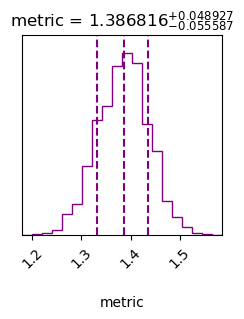

In [ ]:
cornerplot(results_GP, title_fmt='.6f');

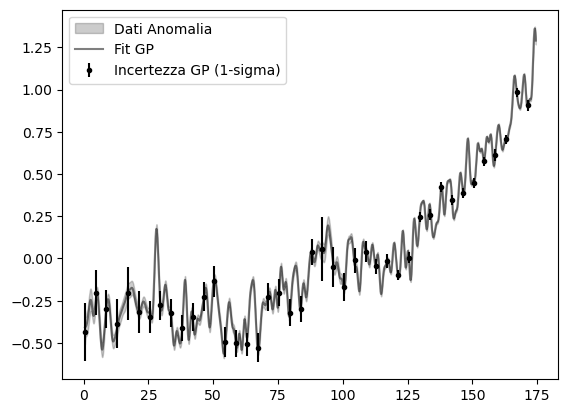

In [ ]:
mean_metric = results_GP['samples'].mean()
time = data_air_masked['time_centered']
anomalies = data_air_masked['Annual_Anomaly']
anomalies_unc = data_air_masked['Annual_Anomaly_Unc']

res_kernel = kernels.ExpSquaredKernel(mean_metric)
res_gp = george.GP(res_kernel)
res_gp.compute(time, anomalies_unc)

pred_anomalies, pred_anomalies_unc = res_gp.predict(anomalies, time, return_var=True)

plt.errorbar(time[::50], anomalies[::50], yerr=anomalies_unc[::50], fmt=".k", capsize=0, zorder=0)
plt.fill_between(time, pred_anomalies - np.sqrt(pred_anomalies_unc), pred_anomalies + np.sqrt(pred_anomalies_unc), color="k", alpha=0.2)
plt.plot(time, pred_anomalies, "k", lw=1.5, alpha=0.5)
plt.legend(['Dati Anomalia', 'Fit GP', 'Incertezza GP (1-sigma)'])


## Gaussian process trend (exp)

In [ ]:
class Exp(Model):
    parameter_names = ("a", "b", "c")

    def get_value(self, t):
        return self.a * np.exp(self.b * t) + self.c

exp_model = george.GP(kernel=kernels.ExpSquaredKernel(1.0), mean=Exp(a=0.0, b=0.0, c=0.0))
exp_model.compute(data_air_masked['time_centered'], data_air_masked['Annual_Anomaly_Unc'])

# print(exp_model.get_parameter_names(include_frozen=True))

def log_likelihood(params):
    exp_model.set_parameter_vector(params)
    return exp_model.log_likelihood(data_air_masked['Annual_Anomaly'], quiet=True)


param_names_GP_trend = ['a', 'b', 'c']
sampler_GP_trend = ReactiveNestedSampler(param_names_GP_trend, loglike=log_likelihood, transform=prior_exponential)
results_GP_trend = sampler_GP_trend.run(min_num_live_points=100)
sampler_GP_trend.print_results()

('mean:a', 'mean:b', 'mean:c', 'white_noise:value', 'kernel:metric:log_M_0_0')


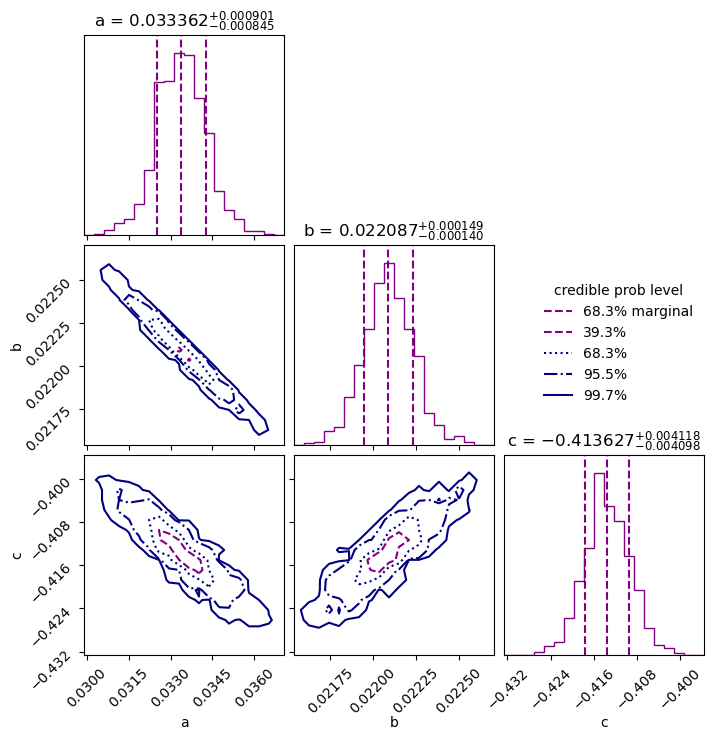

In [ ]:
cornerplot(results_GP_trend, title_fmt='.6f');

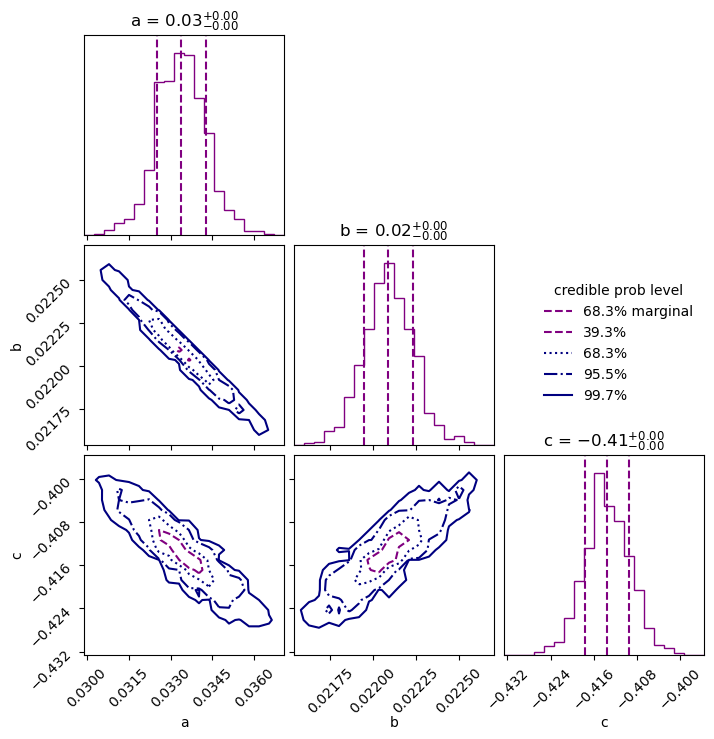

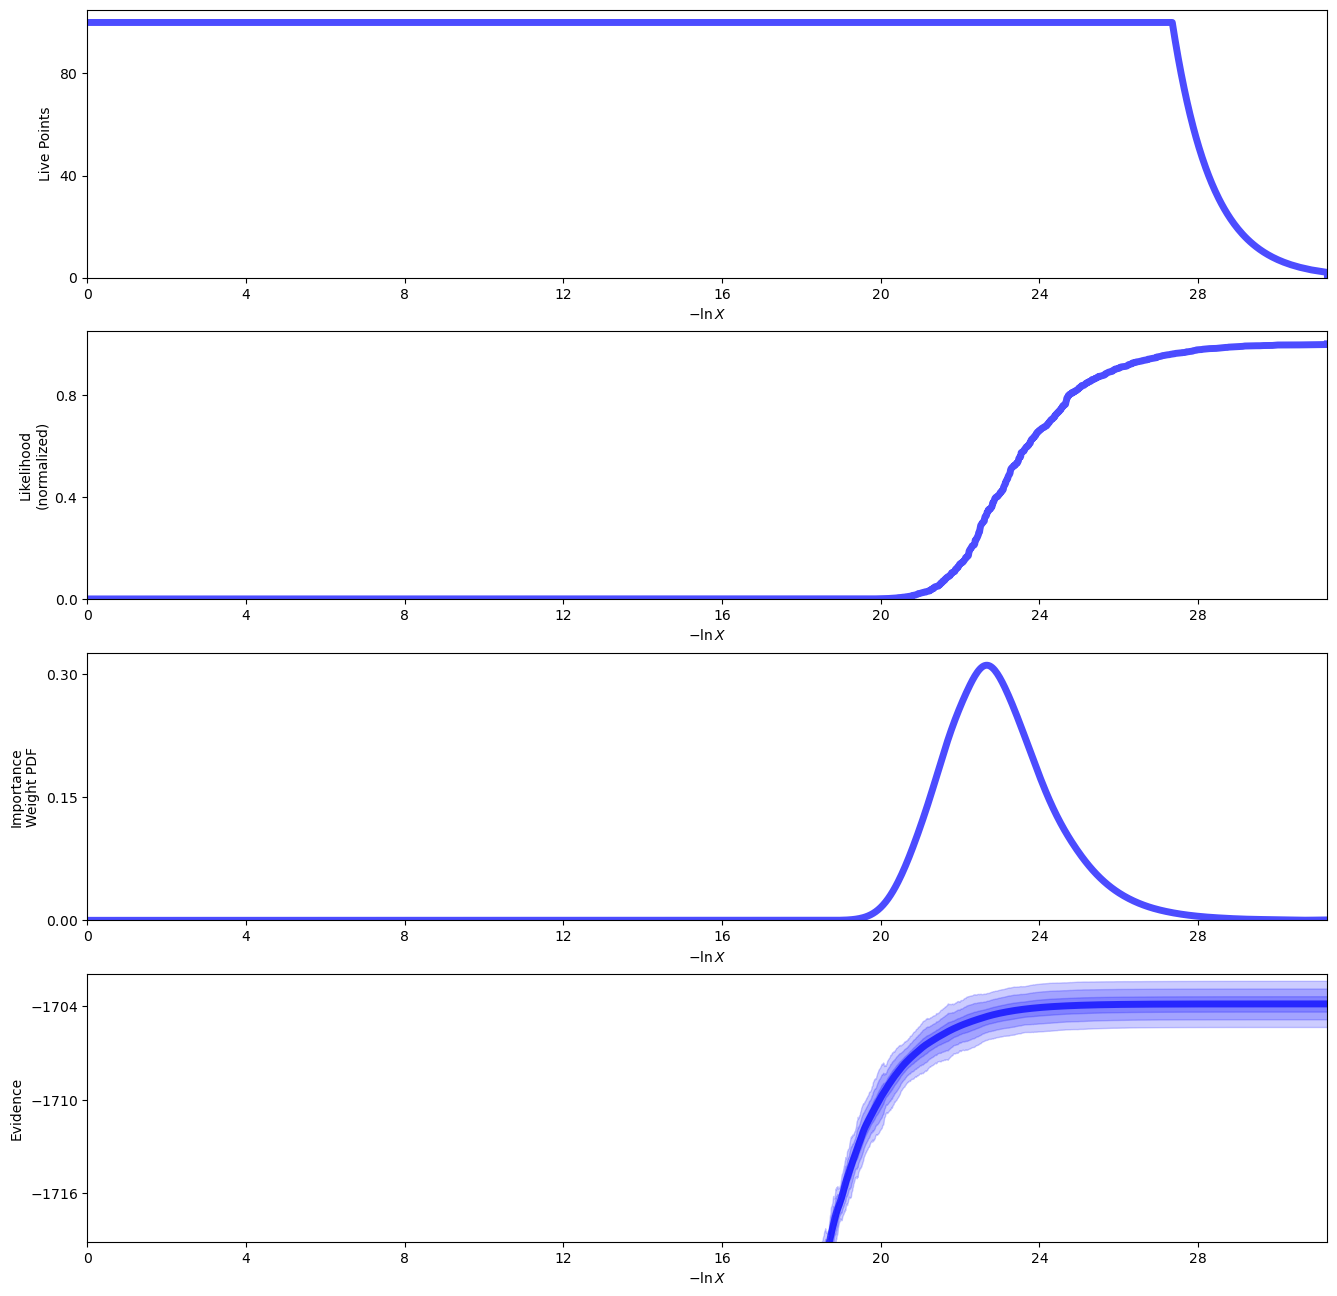

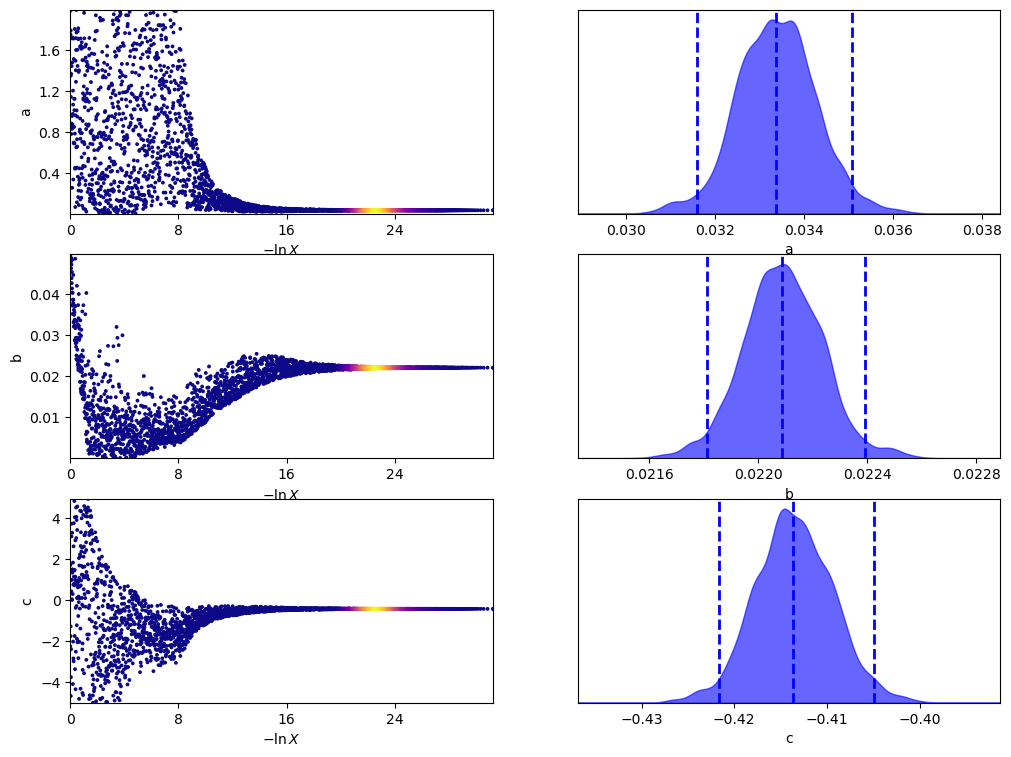

In [ ]:
sampler_GP_trend.plot()

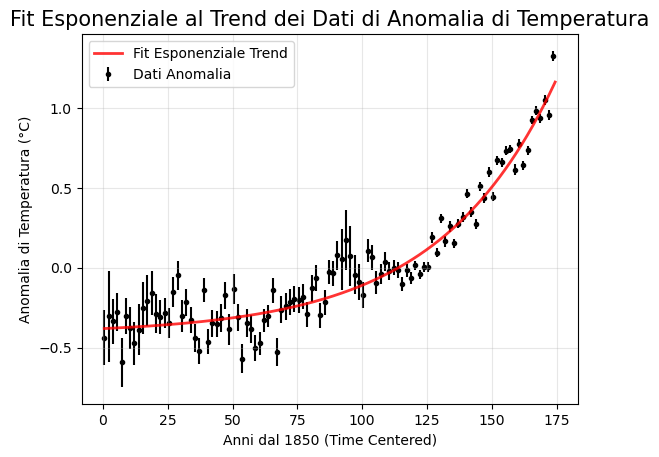

In [ ]:
a = results_GP_trend['samples'][:, 0].mean()
b = results_GP_trend['samples'][:, 1].mean()
c = results_GP_trend['samples'][:, 2].mean()

t = data_air_masked['time_centered']
pred_trend = a * np.exp(b * t) + c

plt.errorbar(t[::20],data_air_masked['Annual_Anomaly'][::20], yerr=data_air_masked['Annual_Anomaly_Unc'][::20], fmt=".k", capsize=0, zorder=0)
plt.plot(t, pred_trend, "r", lw=2, alpha=0.8, label='Fit Esponenziale (Trend)')
plt.legend(['Fit Esponenziale Trend', 'Dati Anomalia'])
plt.title('Fit Esponenziale al Trend dei Dati di Anomalia di Temperatura', fontsize=15)
plt.xlabel('Anni dal 1850 (Time Centered)')
plt.ylabel('Anomalia di Temperatura (°C)')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
class Exp(Model):
    parameter_names = ("a", "b", "c", "amp", "mu", "sigma")

    def get_value(self, t):
        return self.a * np.exp(self.b * t) + self.c + self.amp * np.exp(-0.5 * ((t - self.mu) / self.sigma)**2)

exp_model = george.GP(mean=Exp(a=0.0, b=0.0, c=0.0, amp=0.0, mu=0.0, sigma=1.0))
exp_model.compute(data_air_masked['time_centered'], data_air_masked['Annual_Anomaly_Unc'])

def log_likelihood(params):
    exp_model.set_parameter_vector(params)
    return exp_model.log_likelihood(data_air_masked['Annual_Anomaly'], quiet=True)

def prior_trend(cube):
    params = cube.copy()
    params[0] = cube[0] * 2.0
    params[1] = cube[1] * 0.05
    params[2] = cube[2] * 10 - 5
    params[3] = cube[3] * 1.0
    params[4] = cube[4] * 200.0
    params[5] = cube[5] * 50.0
    
    return params


param_names_GP_trend = ['a', 'b', 'c', 'amp', 'mu', 'sigma']
sampler_GP_trend = ReactiveNestedSampler(param_names_GP_trend, loglike=log_likelihood, transform=prior_trend)
results_GP_trend = sampler_GP_trend.run(min_num_live_points=200)
sampler_GP_trend.print_results()

In [ ]:
arr1 = data_air_masked['time_centered']
arr2 = data_air_masked['Annual_Anomaly']

corr_matrix_time_anomaly = np.corrcoef(arr1, arr2)
correlazione_time_anomaly = corr_matrix_time_anomaly[0, 1]

print(f"Coefficiente di correlazione di Pearson (Time vs Anomalia): {correlazione_time_anomaly:.4f}")

arr3 = data_air_masked['Annual_Anomaly_Unc']
corr_matrix_anomaly_unc = np.corrcoef(arr2, arr3)
correlazione_anomaly_unc = corr_matrix_anomaly_unc[0, 1]

print(f"Coefficiente di correlazione di Pearson (Anomalia vs Incertezza): {correlazione_anomaly_unc:.4f}")

corr_matrix_time_unc = np.corrcoef(arr1, arr3)
correlazione_time_unc = corr_matrix_time_unc[0, 1]

print(f"Coefficiente di correlazione di Pearson (Time vs Incertezza): {correlazione_time_unc:.4f}")

Coefficiente di correlazione di Pearson (Time vs Anomalia): 0.8581
Coefficiente di correlazione di Pearson (Anomalia vs Incertezza): -0.5791
Coefficiente di correlazione di Pearson (Time vs Incertezza): -0.7683


In [ ]:
class Exp(Model):
    parameter_names = ("a", "b", "c")

    def get_value(self, t):
        return self.a * np.exp(self.b * t) + self.c

exp_model = george.GP(kernel = kernels.ExpSquaredKernel(1.0), mean=Exp(a=0.0, b=0.0, c=0.0))
exp_model.compute(data_air_masked['time_centered'], data_air_masked['Annual_Anomaly_Unc'])

def prior_exp_noise(cube):
    params = cube.copy()

    params[0] = cube[0] * 2         
    params[1] = cube[1] * 0.05        
    params[2] = cube[2] * 10.0 - 5.0  
    params[3] = cube[3] * 10.0 -5.0 # log metric

    return params

print(exp_model.get_parameter_names())

def log_likelihood(params):
    exp_model.set_parameter_vector(params)
    return exp_model.log_likelihood(data_air_masked['Annual_Anomaly'], quiet=True)

param_names_GP_trend = ['a', 'b', 'c', 'metric']
sampler_GP_trend = ReactiveNestedSampler(param_names_GP_trend, loglike=log_likelihood, transform=prior_exp_noise)
results_GP_trend = sampler_GP_trend.run(min_num_live_points=100)
sampler_GP_trend.print_results()

('mean:a', 'mean:b', 'mean:c', 'kernel:metric:log_M_0_0')
[ultranest] Sampling 100 live points from prior ...


KeyboardInterrupt: 